In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
preprocessed_df=pd.read_csv('UKBB_preprocessed.csv')
preprocessed_df.head()

,Broad_ID,gene1,gene2,gene3,VAF1,VAF2,VAF3,sex,CH_score,eid,...,MRV,MspCV,immret,hiscatret,age,year_of_assessment,year_HM,HM_type,CHRS,MN
0,3463778,NaN,NaN,NaN,NaN,NaN,NaN,1,0.0,4726860.0,...,111.23,82.09,0.211,0.014,42.000000,2009.666667,NaN,NaN,0.0,0
1,2821197,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0,1633945.0,...,104.46,81.47,0.214,0.009,47.000000,2009.666667,NaN,NaN,0.0,0
2,1514525,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0,4596360.0,...,106.56,86.68,0.228,0.005,52.416667,2009.666667,NaN,NaN,0.0,0
3,2491905,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0,3143018.0,...,111.75,83.24,0.360,0.030,65.750000,2009.666667,NaN,NaN,0.0,0
4,3250377,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0,2254568.0,...,107.37,82.90,0.271,0.021,57.000000,2009.666667,NaN,NaN,0.0,0


In [4]:
# Hpw many participants had CH?
tot=len(preprocessed_df)
CH=len(preprocessed_df[preprocessed_df['CHRS']>0])
MN=len(preprocessed_df[preprocessed_df['MN']==1])
CHMN = len(preprocessed_df[(preprocessed_df['CHRS']>0)&(preprocessed_df['MN']==1)])

print("Total number of participants, after exclusions:",tot)
print("Number of participants with CH:", CH, (CH*100/tot),"%")
print("Number of participants with MN:", MN, (MN*100/tot),"%")
print("Number of participants with CH who have MN:", CHMN)

Total number of participants, after exclusions: 461620
Number of participants with CH: 28817 6.242580477448984 %
Number of participants with MN: 1641 0.3554871972618171 %
Number of participants with CH who have MN: 529


## 1. Genetic Data - Molecular CH score, CHRS and MN ##

In [95]:
df_gene=preprocessed_df[['gene1','gene2','gene3','VAF1','VAF2','VAF3','sex','CH_score','age','MN','CHRS']]

### 1.1  EDA on molecular CH score  ###

In [10]:
df_gene['CH_score'].value_counts()

CH_score
0.0    432803
3.5     13292
4.0      9065
5.0      2766
4.5      1574
5.5      1066
6.0       491
6.5       392
7.5       171
Name: count, dtype: int64

Text(0, 0.5, 'Counts')

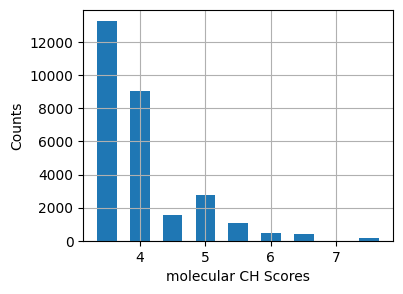

In [43]:
df_sel=df_gene.loc[df_gene['CH_score']>0]
value_counts=df_sel['CH_score'].value_counts()
values=value_counts.index.tolist()
counts=value_counts.values.tolist()
plt.figure(figsize=(4,3))
plt.bar(values,counts,width=0.3)
plt.grid()
plt.xlabel("molecular CH Scores")
plt.ylabel("Counts")

Point-Biserial Correlation: 0.2507
P-value: 0.0000e+00
Group: 0, Q1: 3.50,Q2: 4.00, Q3: 4.00, IQR: 0.50
Group: 1, Q1: 4.00,Q2: 5.50, Q3: 6.50, IQR: 2.50


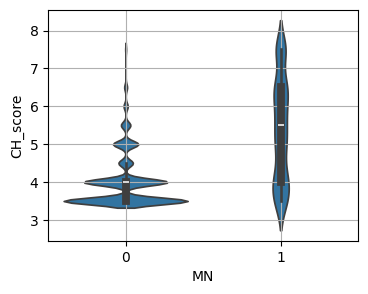

In [28]:
# Violin plots for CH_score vs MN
from scipy import stats

dist1=df_sel[df_sel['MN']==0]['CH_score']
dist2=df_sel[df_sel['MN']==1]['CH_score']

# Compute point-biserial correlation
r_pb, p_value = stats.pointbiserialr(df_sel['CH_score'], df_sel['MN'])

# Print results
print(f"Point-Biserial Correlation: {r_pb:.4f}")
print(f"P-value: {p_value:.4e}")
plt.figure(figsize=(4, 3))
#sns.boxplot(x=df_EDA['MN'], y=df_EDA['CH_score'])
sns.violinplot(x=df_sel['MN'], y=df_sel['CH_score'])

plt.grid()

groups = df_sel['MN'].unique()

for group in groups:
    group_data = df_sel[df_sel['MN'] == group]['CH_score']
    q1 = np.percentile(group_data, 25)
    q2= np.percentile(group_data, 50)
    q3 = np.percentile(group_data, 75)
    iqr = q3 - q1
    print(f"Group: {group}, Q1: {q1:.2f},Q2: {q2:.2f}, Q3: {q3:.2f}, IQR: {iqr:.2f}")

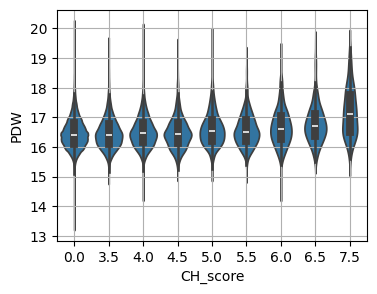

In [33]:
# Violing plots of CH_score for age and other covariates

plt.figure(figsize=(4, 3))
sns.violinplot(x=preprocessed_df['CH_score'], y=preprocessed_df['PDW'])
plt.grid()
#plt.ylim(70,120)

In [125]:
print(len(df_gene.loc[(df_gene['CH_score']==0)]),len(df_gene.loc[(df_gene['CH_score']==0)&(df_gene['MN']==1)]))
print(len(df_gene.loc[(df_gene['CH_score']>0)&(df_gene['CH_score']<4.5)]),len(df_gene.loc[(df_gene['CH_score']>0)&(df_gene['CH_score']<4)&(df_gene['MN']==1)]))
print(len(df_gene.loc[(df_gene['CH_score']>4)&(df_gene['CH_score']<6)]),len(df_gene.loc[(df_gene['CH_score']>4)&(df_gene['CH_score']<6)&(df_gene['MN']==1)]))
print(len(df_gene.loc[(df_gene['CH_score']>=6)]),len(df_gene.loc[(df_gene['CH_score']>=6)&(df_gene['MN']==1)]))

432803 1112
22357 77
5406 143
1054 221


Text(0, 0.5, 'Incident MN %')

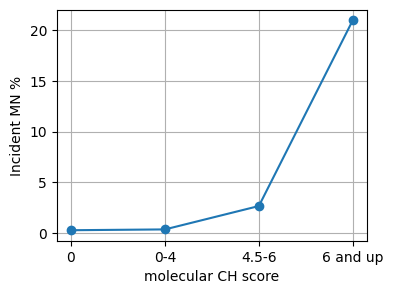

In [126]:
score=['0','0-4','4.5-6','6 and up']
x=[0,1,2,3]
values=[0.26,0.34,2.65,21]
plt.figure(figsize=(4,3))
plt.plot(x,values,'-o')
plt.xticks(ticks=x, labels=score)
plt.grid()
plt.xlabel('molecular CH score')
plt.ylabel('Incident MN %')

### 1.2 EDA on CHRS ###

In [64]:
df_gene['CHRS'].value_counts()

CHRS
0.0     432803
8.0       9351
7.5       8407
8.5       3682
9.0       2605
9.5       2294
10.0      1031
10.5       610
11.0       347
11.5       157
12.0       141
12.5        74
13.0        46
13.5        41
14.0        24
14.5         4
15.0         2
15.5         1
Name: count, dtype: int64

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


Text(0, 0.5, 'Counts')

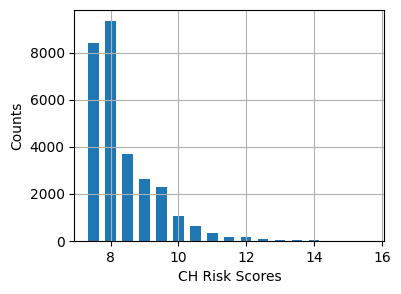

In [44]:
df_sel=df_gene.loc[df_gene['CHRS']>0]
value_counts=df_sel['CHRS'].value_counts()
values=value_counts.index.tolist()
counts=value_counts.values.tolist()
plt.figure(figsize=(4,3))
plt.bar(values,counts,width=0.3)
plt.grid()
plt.xlabel("CH Risk Scores")
plt.ylabel("Counts")

Point-Biserial Correlation: 0.2814
P-value: 0.0000e+00
Group: 0, Q1: 7.50,Q2: 8.00, Q3: 8.50, IQR: 1.00
Group: 1, Q1: 9.00,Q2: 10.00, Q3: 12.00, IQR: 3.00


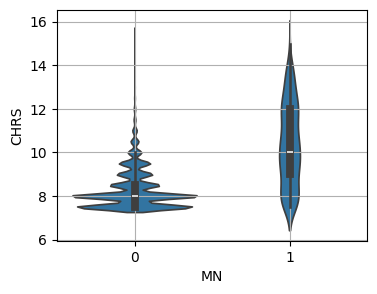

In [45]:
# Violin plots for CHRS vs MN
from scipy import stats

dist1=df_sel[df_sel['MN']==0]['CHRS']
dist2=df_sel[df_sel['MN']==1]['CHRS']

# Compute point-biserial correlation
r_pb, p_value = stats.pointbiserialr(df_sel['CHRS'], df_sel['MN'])

# Print results
print(f"Point-Biserial Correlation: {r_pb:.4f}")
print(f"P-value: {p_value:.4e}")
plt.figure(figsize=(4, 3))
#sns.boxplot(x=df_EDA['MN'], y=df_EDA['CH_score'])
sns.violinplot(x=df_sel['MN'], y=df_sel['CHRS'])

plt.grid()

groups = df_sel['MN'].unique()

for group in groups:
    group_data = df_sel[df_sel['MN'] == group]['CHRS']
    q1 = np.percentile(group_data, 25)
    q2= np.percentile(group_data, 50)
    q3 = np.percentile(group_data, 75)
    iqr = q3 - q1
    print(f"Group: {group}, Q1: {q1:.2f},Q2: {q2:.2f}, Q3: {q3:.2f}, IQR: {iqr:.2f}")

In [73]:
print(len(df_gene.loc[(df_gene['CHRS']==0)]),len(df_gene.loc[(df_gene['CHRS']==0)&(df_gene['MN']==1)]))
print(len(df_gene.loc[(df_gene['CHRS']>0)&(df_gene['CHRS']<10)]),len(df_gene.loc[(df_gene['CHRS']>0)&(df_gene['CHRS']<10)&(df_gene['MN']==1)]))
print(len(df_gene.loc[(df_gene['CHRS']>=10)&(df_gene['CHRS']<12.5)]),len(df_gene.loc[(df_gene['CHRS']>=10)&(df_gene['CH_score']<12.5)&(df_gene['MN']==1)]))
print(len(df_gene.loc[(df_gene['CHRS']>=12.5)]),len(df_gene.loc[(df_gene['CHRS']>=12.5)&(df_gene['MN']==1)]))

432803 1112
26339 218
2286 311
192 99


Text(0, 0.5, 'Incident MN %')

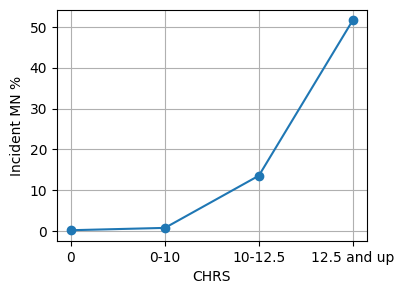

In [76]:
score=['0','0-10','10-12.5','12.5 and up']
x=[0,1,2,3]
values=[0.26,0.83,13.6,51.6]
plt.figure(figsize=(4,3))
plt.plot(x,values,'-o')
plt.xticks(ticks=x, labels=score)
plt.grid()
plt.xlabel('CHRS')
plt.ylabel('Incident MN %')

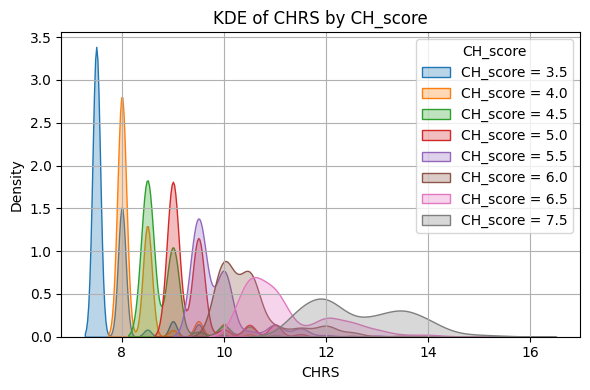

In [81]:
# --- choose which column we plot, and which column defines the groups ---
x_col      = 'CHRS'       # distribution you want on the x‑axis
group_col  = 'CH_score'   # defines the groups / separate curves

# --- find the groups we’ll iterate over ---
groups = sorted(df_sel[group_col].dropna().unique())   # list of distinct CH_score values

plt.figure(figsize=(6,4))

for g in groups:
    subset = df_sel[df_sel[group_col] == g][x_col].dropna()
    if len(subset) < 2:               # too few points → skip, KDE can’t be estimated
        continue
    sns.kdeplot(subset,
                fill=True, alpha=0.3,
                label=f'{group_col} = {g}')

plt.xlabel(x_col)
plt.ylabel('Density')
plt.title(f'KDE of {x_col} by {group_col}')
plt.grid(True)
plt.legend(title=group_col, loc='upper right')
plt.tight_layout()
plt.show()


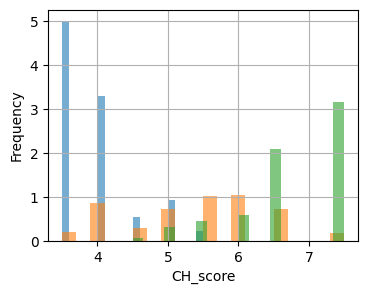

In [113]:
CHRS0=df_gene.loc[df_gene['CHRS']==0]['CH_score']
CHRS1=df_gene.loc[(df_gene['CHRS']>0)&(df_gene['CHRS']<10)]['CH_score']
CHRS2=df_gene.loc[(df_gene['CHRS']>=10)&(df_gene['CHRS']<12.5)]['CH_score']
CHRS3=df_gene.loc[df_gene['CHRS']>12]['CH_score']

plt.figure(figsize=(4, 3))
#plt.hist(CHRS0, bins=20, density=True, alpha=0.6, label='CHRS = 0')
plt.hist(CHRS1, bins=20, density=True,alpha=0.6, label='0 < CHRS < 10')
plt.hist(CHRS2, bins=20, density=True,alpha=0.6, label='10 ≤ CHRS < 12.5')
plt.hist(CHRS3, bins=20, density=True,alpha=0.6, label='CHRS > 12')
plt.xlabel('CH_score')
plt.ylabel('Frequency')
plt.grid()

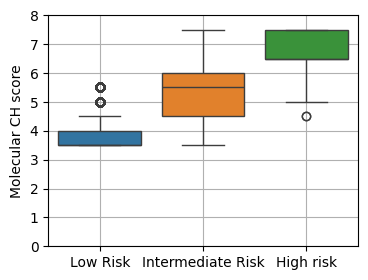

In [124]:
data = [CHRS1.values, CHRS2.values, CHRS3.values]
labels = ['Low Risk', 'Intermediate Risk', 'High risk']

plt.figure(figsize=(4, 3))
sns.boxplot(data=data)
plt.xticks(ticks=range(3), labels=labels)
plt.ylabel('Molecular CH score')
plt.ylim(0,8)
plt.grid()

In [88]:
df_sel2=df_gene[df_gene['CHRS']>10]
print(len(df_sel2), df_sel2['CH_score'].min())

1447 3.5


In [104]:
preprocessed_df.loc[(preprocessed_df['CHRS']>=10)&(preprocessed_df['CH_score']<=4)][['RDW','platelet','RBC','MCV','age','neutrophil']]

,RDW,platelet,RBC,MCV,age,neutrophil
440,19.12,337.1,5.045,83.41,65.250000,6.01
710,16.11,300.7,4.405,80.66,66.750000,6.14
2309,17.00,333.0,3.600,105.10,56.583333,7.80
3949,20.40,323.0,3.370,66.50,46.083333,3.70
4254,15.42,132.2,4.269,97.15,66.000000,3.42
...,...,...,...,...,...,...
458967,15.00,177.3,4.699,94.68,66.333333,6.10
459722,17.30,417.0,4.380,80.40,56.583333,4.10
460037,12.30,217.0,3.770,100.40,65.083333,3.80
460990,15.00,296.0,3.670,92.00,51.750000,3.80


* 479 participants have abnormal blood counts, and/or are above 65, leading to a CHRS of >=10 despite no molecular signatures of high risk CH. These participants will be further screened anyways.

### 1.3 Comparison of cohorts with and without incident MN ###

In [57]:
df_gene['MN'].value_counts()

MN
0    459979
1      1641
Name: count, dtype: int64

In [99]:
# How many people without CH gets MN, and how many with CH get MN

print(len(df_gene[(df_gene['CHRS']==0)]),len(df_gene[(df_gene['CHRS']==0)&(df_gene['MN']==1)]))
print(len(df_gene[(df_gene['CHRS']>0)]),len(df_gene[(df_gene['CHRS']>0)&(df_gene['MN']==1)]))

432803 1112
28817 529


<Figure size 400x300 with 0 Axes>

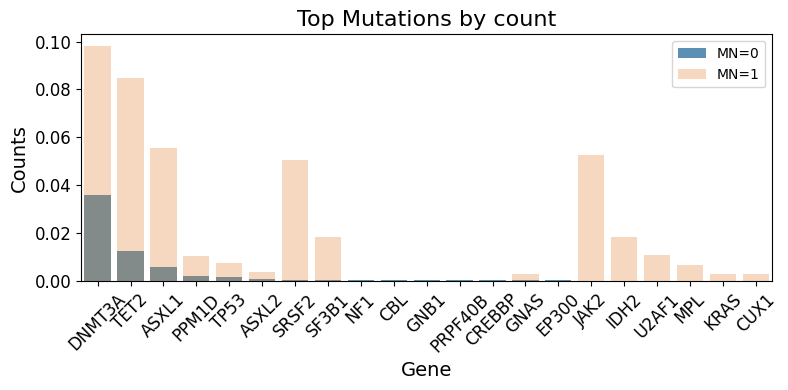

In [46]:
df_EDA1=df_gene[df_gene['MN']==0].copy()
df_EDA2=df_gene[df_gene['MN']==1].copy()
plt.figure(figsize=(4,3))

## driver genes: the 10 most commonly occuring mutations
mutations1=pd.concat([df_EDA1['gene1'],df_EDA1['gene2'],df_EDA1['gene3']])
mutations2=pd.concat([df_EDA2['gene1'],df_EDA2['gene2'],df_EDA2['gene3']])
counts1=mutations1.value_counts().head(15)
counts2=mutations2.value_counts().head(15)

# Plot the bar plot
plt.figure(figsize=(8, 4))
sns.barplot(x=counts1.index, y=counts1.values/len(df_EDA1),alpha=0.8,label='MN=0')
sns.barplot(x=counts2.index, y=counts2.values/len(df_EDA2),alpha=0.3,label='MN=1')
plt.title('Top Mutations by count', fontsize=16)
plt.xlabel('Gene', fontsize=14)
plt.ylabel('Counts', fontsize=14)
plt.legend(loc='best')
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()

163
1659
26765


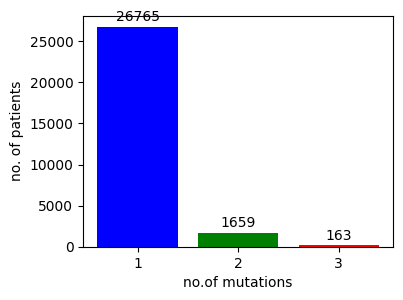

In [52]:

# Number of patients with 1,2,3 genes mutated
mut_3 = df_EDA1[['gene1', 'gene2', 'gene3']].notna().all(axis=1).sum()
print(mut_3)
mut_2 = (df_EDA1[['gene1', 'gene2', 'gene3']].notna().sum(axis=1)== 2).sum()
print(mut_2)
mut_1 = (df_EDA1[['gene1', 'gene2', 'gene3']].notna().sum(axis=1)== 1).sum()
print(mut_1)
'''
# Number of patients with 1,2,3 genes mutated
mut_3 = df_EDA2[['gene1', 'gene2', 'gene3']].notna().all(axis=1).sum()
print(mut_3)
mut_2 = (df_EDA2[['gene1', 'gene2', 'gene3']].notna().sum(axis=1)== 2).sum()
print(mut_2)
mut_1 = (df_EDA2[['gene1', 'gene2', 'gene3']].notna().sum(axis=1)== 1).sum()
print(mut_1)
'''
plt.figure(figsize=(4, 3))
values=[mut_3,mut_2,mut_1]
labels=[3,2,1]
colors=['red','green','blue']
bars = plt.bar(labels, values, color=colors)
plt.bar_label(bars, padding=2, fmt='%d')
plt.xlabel('no.of mutations')
plt.ylabel('no. of patients')
plt.xticks([1,2,3]);

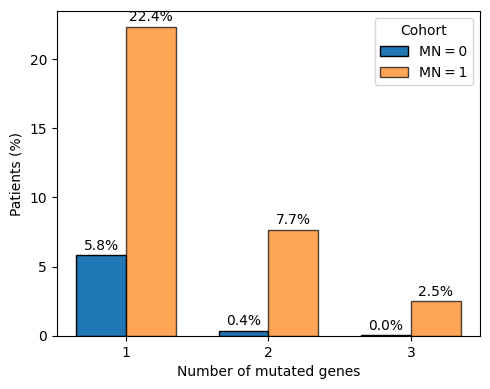

In [55]:
import matplotlib.pyplot as plt
import numpy as np

# ---------- Helper: count # of mutated genes per patient ----------
def mutation_counts(df, gene_cols):
    n_mut = df[gene_cols].notna().sum(axis=1)
    return {1: (n_mut == 1).sum(),
            2: (n_mut == 2).sum(),
            3: (n_mut == 3).sum()}

gene_cols = ['gene1', 'gene2', 'gene3']

eda1_counts = mutation_counts(df_EDA1, gene_cols)
eda2_counts = mutation_counts(df_EDA2, gene_cols)

# ----- Convert to percentages (divide by cohort size) -----
n_eda1 = len(df_EDA1)          # total patients in EDA1
n_eda2 = len(df_EDA2)          # total patients in EDA2
eda1_pct = {k: v / n_eda1 * 100 for k, v in eda1_counts.items()}
eda2_pct = {k: v / n_eda2 * 100 for k, v in eda2_counts.items()}

# ---------- Plot ----------
labels    = np.array([1, 2, 3])
eda1_vals = [eda1_pct[i] for i in labels]
eda2_vals = [eda2_pct[i] for i in labels]

bar_width = 0.35
x         = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(5,4))

ax.bar(x - bar_width/2, eda1_vals, width=bar_width,
       label='MN = 0', edgecolor='black')
ax.bar(x + bar_width/2, eda2_vals, width=bar_width,
       label='MN = 1', edgecolor='black', alpha=0.7)

ax.set_xlabel('Number of mutated genes')
ax.set_ylabel('Patients (%)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend(title='Cohort')

# annotate bars with percentage labels
for bars in ax.containers:
    ax.bar_label(bars, padding=2, fmt='%.1f%%')

plt.tight_layout()
plt.show()

4.011983880090498
5.37523629489603


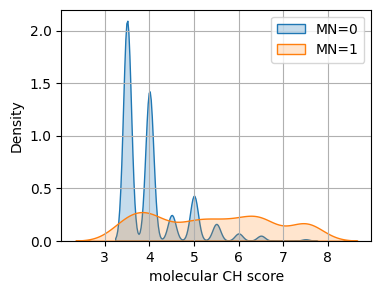

In [71]:
# KDE plots of molecular CH score for the MN and no-MN cohorts, only for patients with presence of CH

plt.figure(figsize=(4,3))
print(df_sel[df_sel['MN']==0]['CH_score'].mean())
print(df_sel[df_sel['MN']==1]['CH_score'].mean())
sns.kdeplot(df_sel[df_sel['MN']==0]['CH_score'],fill=True,label='MN=0');
sns.kdeplot(df_sel[df_sel['MN']==1]['CH_score'],fill=True,alpha=0.2,label='MN=1');
plt.legend()
plt.xlabel('molecular CH score')
plt.grid()
#plt.xlim(2.5,7.5)
#plt.ylim(0,0.1)

8.323582437782806
10.36578449905482


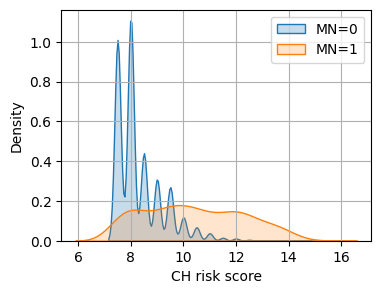

In [72]:
# KDE plots of CHRS for the MN and no-MN cohorts, only for patients with presence of CH

plt.figure(figsize=(4,3))
print(df_sel[df_sel['MN']==0]['CHRS'].mean())
print(df_sel[df_sel['MN']==1]['CHRS'].mean())
sns.kdeplot(df_sel[df_sel['MN']==0]['CHRS'],fill=True,label='MN=0');
sns.kdeplot(df_sel[df_sel['MN']==1]['CHRS'],fill=True,alpha=0.2,label='MN=1');
plt.legend()
plt.xlabel('CH risk score')
plt.grid()

## 2. Blood Count Paramters ##

In [39]:
columns_to_drop=['Broad_ID','gene1','gene2','gene3','VAF1','VAF2','VAF3','sex','CH_score','eid','age',
                 'year_of_assessment','year_HM','HM_type','MN','CHRS']
df_blood=preprocessed_df.drop(columns=columns_to_drop)
df_blood.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 461620 entries, 0 to 461619
Data columns (total 23 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   WBC           461620 non-null  float64
 1   RBC           461620 non-null  float64
 2   Hbconc        461620 non-null  float64
 3   haematocrit   461620 non-null  float64
 4   MCV           461620 non-null  float64
 5   MCHb          461620 non-null  float64
 6   MCHbconc      461620 non-null  float64
 7   RDW           461620 non-null  float64
 8   platelet      461620 non-null  float64
 9   plateletcrit  461620 non-null  float64
 10  MPV           461620 non-null  float64
 11  PDW           461620 non-null  float64
 12  lymphocyte    461620 non-null  float64
 13  monocyte      461620 non-null  float64
 14  neutrophil    461620 non-null  float64
 15  eosinophil    461620 non-null  float64
 16  basophil      461620 non-null  float64
 17  nucRBC        461620 non-null  float64
 18  reti

Text(0.5, 1.0, 'Correlation Heatmap')

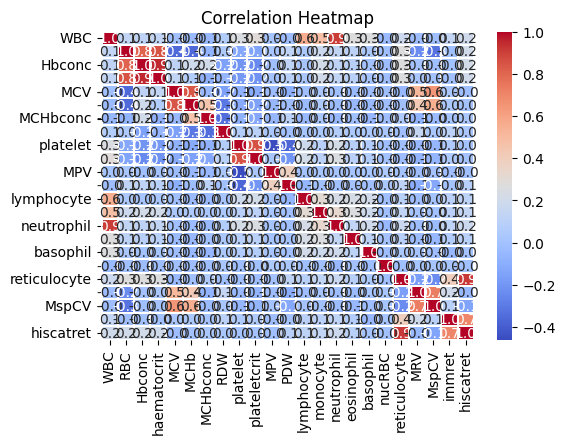

In [41]:
correlation_matrix=df_blood.corr(method='spearman')

# Plot the correlation heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".1f", linewidths=0.1)
plt.title('Correlation Heatmap')

### 2.1 PDW and a cutoff of giant platelet ###

Mean: 16.49
Median: 16.42
Standard Deviation: 0.52


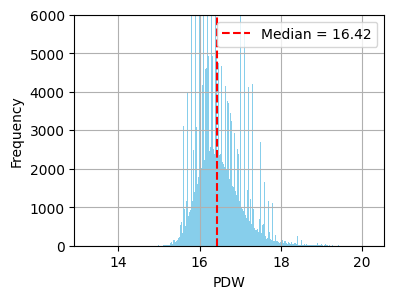

In [135]:
# Compute statistics
mean_val = preprocessed_df['PDW'].mean()
median_val = preprocessed_df['PDW'].median()
std_val = preprocessed_df['PDW'].std()

# Print stats
print(f"Mean: {mean_val:.2f}")
print(f"Median: {median_val:.2f}")
print(f"Standard Deviation: {std_val:.2f}")

# Plot histogram with median line
plt.figure(figsize=(4, 3))
plt.hist(preprocessed_df['PDW'], bins=500, color='skyblue')
plt.axvline(median_val, color='red', linestyle='--', label=f'Median = {median_val:.2f}')
plt.xlabel('PDW')
plt.ylabel('Frequency')
plt.grid(True)
plt.ylim(0,6000)
plt.legend()

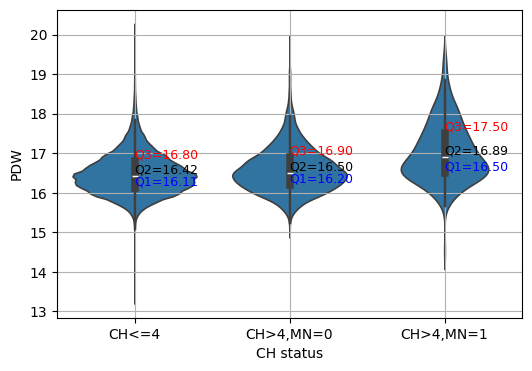

In [145]:
df_LR=preprocessed_df[preprocessed_df['CH_score']<=4][['PDW']]
df_MR=preprocessed_df[(preprocessed_df['CH_score']>4)&(preprocessed_df['MN']==0)][['PDW']]
df_HR=preprocessed_df[(preprocessed_df['CH_score']>4)&(preprocessed_df['MN']==1)][['PDW']]

# Prepare long-form DataFrame for violin plot
df_violin = pd.concat([
    pd.DataFrame({'PDW': df_LR['PDW'].values, 'CH status': 'CH<=4'}),
    pd.DataFrame({'PDW': df_MR['PDW'].values, 'CH status': 'CH>4,MN=0'}),
    pd.DataFrame({'PDW': df_HR['PDW'].values, 'CH status': 'CH>4,MN=1'})
])

# Plot violin
plt.figure(figsize=(6, 4))
sns.violinplot(x='CH status', y='PDW', data=df_violin, inner='box', linewidth=1.2)

# Annotate quartiles manually
for i, label in enumerate(['CH<=4', 'CH>4,MN=0', 'CH>4,MN=1']):
    group = df_violin[df_violin['CH status'] == label]['PDW'].dropna()
    q1, q2, q3 = np.percentile(group, [25, 50, 75])
    plt.text(i, q1, f'Q1={q1:.2f}', ha='left', va='bottom', fontsize=9, color='blue')
    plt.text(i, q2, f'Q2={q2:.2f}', ha='left', va='bottom', fontsize=9, color='black')
    plt.text(i, q3, f'Q3={q3:.2f}', ha='left', va='bottom', fontsize=9, color='red')

plt.ylabel('PDW')
plt.grid()

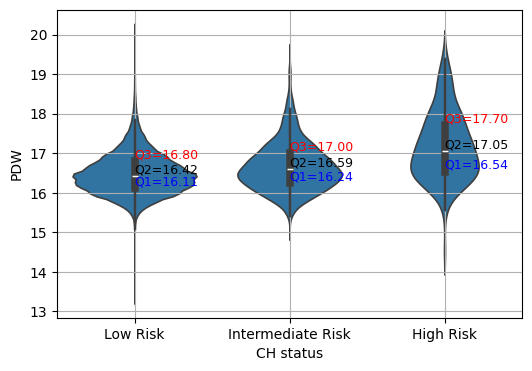

In [147]:
df_LR=preprocessed_df[preprocessed_df['CHRS']<10][['PDW']]
df_MR=preprocessed_df[(preprocessed_df['CHRS']>=10)&(preprocessed_df['CHRS']<=12)][['PDW']]
df_HR=preprocessed_df[(preprocessed_df['CHRS']>12)][['PDW']]

# Prepare long-form DataFrame for violin plot
df_violin = pd.concat([
    pd.DataFrame({'PDW': df_LR['PDW'].values, 'CH status': 'Low Risk'}),
    pd.DataFrame({'PDW': df_MR['PDW'].values, 'CH status': 'Intermediate Risk'}),
    pd.DataFrame({'PDW': df_HR['PDW'].values, 'CH status': 'High Risk'})
])

# Plot violin
plt.figure(figsize=(6, 4))
sns.violinplot(x='CH status', y='PDW', data=df_violin, inner='box', linewidth=1.2)

# Annotate quartiles manually
for i, label in enumerate(['Low Risk', 'Intermediate Risk', 'High Risk']):
    group = df_violin[df_violin['CH status'] == label]['PDW'].dropna()
    q1, q2, q3 = np.percentile(group, [25, 50, 75])
    plt.text(i, q1, f'Q1={q1:.2f}', ha='left', va='bottom', fontsize=9, color='blue')
    plt.text(i, q2, f'Q2={q2:.2f}', ha='left', va='bottom', fontsize=9, color='black')
    plt.text(i, q3, f'Q3={q3:.2f}', ha='left', va='bottom', fontsize=9, color='red')

plt.ylabel('PDW')
plt.grid()